# Notebook final — Modélisation pré-voyage et post-voyage

Ce notebook reprend les étapes stabilisées du projet IA de planification de séjours :

1. chargement du dataset ;
2. contrôles de cohérence métier ;
3. nettoyage et préparation des données ;
4. feature engineering ;
5. modèle pré-voyage ;
6. modèle post-voyage ;
7. comparaison, choix du modèle et préparation de l'étape suivante.

Les notebooks d'expérimentation restent conservés séparément. Ce notebook sert de version propre pour la suite du projet.

## 1. Cadrage et analyse du besoin

### 1.1 Définition du problème métier

L'agence de voyages souhaite améliorer la personnalisation des séjours et la satisfaction client à partir de l'historique des voyages. Le problème métier concret est double :

- avant le départ, estimer si les informations disponibles lors de la planification suffisent à anticiper la satisfaction client ;
- après le séjour, identifier les facteurs opérationnels associés à une satisfaction faible ou élevée afin d'améliorer les futures propositions.

La cible métier étudiée est `satisfaction_client`. Le projet distingue donc volontairement deux cas d'usage : un objectif pré-voyage, utile pour la planification, et un objectif post-voyage, utile pour l'analyse qualité et l'amélioration continue.

### 1.2 Objectifs IA retenus et règles de fuite de données

| Objectif | Moment d'utilisation | Variables autorisées | Variables exclues |
| --- | --- | --- | --- |
| Pré-voyage | Avant le départ | profil, budget, destination, saison, durée, hébergement, météo prévue, activité | `imprevus`, `reorganisation_necessaire`, `respect_budget`, `retour_client` |
| Post-voyage | Après ou pendant le séjour | variables pré-voyage + événements opérationnels observés | `retour_client` brut et variables NLP dérivées |

Pour le modèle post-voyage final, la satisfaction est regroupée en 3 classes :

- `0` : insatisfait, notes 1 et 2 ;
- `1` : neutre, note 3 ;
- `2` : satisfait, notes 4 et 5.

Cette séparation évite la fuite de données : les variables connues uniquement pendant ou après le séjour ne doivent pas être utilisées pour prédire la satisfaction avant le départ.

### 1.3 Indicateurs de succès du projet

| KPI | Rôle dans le projet | Seuil ou interprétation attendue |
| --- | --- | --- |
| `macro_f1` | Mesurer la performance globale en tenant compte des classes minoritaires | Indicateur principal pour comparer les modèles |
| `balanced_accuracy` | Vérifier que le modèle ne favorise pas uniquement la classe majoritaire | Doit être supérieur au modèle naïf `Dummy` |
| Matrice de confusion | Identifier les classes les plus confondues | La classe `neutre` est surveillée spécifiquement |
| Stabilité en validation croisée | Vérifier que le score ne dépend pas d'un seul découpage train/test | Écart-type faible recherché |
| Cohérence métier des variables importantes | Vérifier que le modèle s'appuie sur des signaux interprétables | Les variables post-voyage doivent ressortir dans l'objectif post-voyage |
| Absence de fuite de données | Garantir que le modèle respecte le moment d'utilisation prévu | Obligatoire pour comparer pré-voyage et post-voyage |

### 1.4 Contraintes du projet

| Contrainte | Impact sur le projet |
| --- | --- |
| Données synthétiques | Les résultats servent de preuve de méthode, pas de validation opérationnelle sur clients réels. |
| Volume limité, environ 1500 lignes | Les modèles complexes risquent de surapprendre et les performances restent sensibles au split train/test. |
| Ressources machine limitées | Les traitements trop lourds, notamment NLP avancé ou optimisation massive, doivent être évités ou isolés. |
| Délai de projet de certification | Priorité à une démarche claire, reproductible et documentée plutôt qu'à une optimisation excessive. |
| Contraintes RGPD | Le projet actuel utilise des données synthétiques ; toute donnée réelle nécessiterait un cadrage RGPD renforcé. |
| Industrialisation reportée | Le notebook final doit rester propre et complet avant de figer un pipeline de production. |

### 1.5 L'IA est-elle nécessaire ?

Une solution simple suffit pour certaines parties du projet : règles métier, tableaux de bord, contrôles de cohérence et statistiques descriptives permettent déjà d'identifier des anomalies et des facteurs de risque.

L'IA devient pertinente uniquement si l'objectif est de généraliser ces observations à de nouveaux séjours et de produire une estimation automatisée de la satisfaction. Les expériences du notebook montrent cependant que :

- le cas pré-voyage contient peu de signal prédictif avec les variables disponibles ;
- le cas post-voyage est plus cohérent pour l'analyse qualité, car il utilise les événements réellement observés pendant le séjour ;
- le modèle doit rester une aide à la décision, et non un système de décision automatique.

## 2. Documentation metier et datasheet

objectif dataset, datasheet, variables principales et principes de preparation des donnees.



### 2.1 Datasheet structurée du jeu de données

Cette sous-section formalise la datasheet du fichier `data/Examen_travel_planning_dataset.csv` selon les dimensions attendues pour documenter un jeu de données utilisé dans un projet IA.

#### Motivation et contexte de collecte

Le dataset est utilisé dans le cadre d'un projet de planification de voyages. L'objectif métier est d'analyser des séjours passés afin de comprendre les facteurs associés à la satisfaction client et d'évaluer la possibilité de construire un modèle de prédiction. Les données sont synthétiques et anonymisées ; elles ne proviennent donc pas d'une collecte client réelle, mais simulent des situations plausibles de voyages avec budgets, destinations, contraintes, imprévus et retours clients.

#### Composition et statistiques descriptives

Le fichier contient environ 1500 lignes et 15 colonnes. Chaque ligne représente un séjour. Les variables couvrent le profil client, le budget, la destination, la saison, la durée, l'hébergement, le prix du vol, la météo prévue, l'activité principale, les imprévus, la réorganisation, le respect du budget, la satisfaction client et le retour textuel. Les statistiques descriptives sont vérifiées dans le notebook : valeurs manquantes, distribution de la cible, types de variables, valeurs uniques, doublons, incohérences métier et valeurs atypiques.

#### Usages recommandés

Le dataset est adapté à l'exploration de données, à l'analyse de cohérence métier, à la comparaison entre un objectif pré-voyage et un objectif post-voyage, ainsi qu'à la construction d'un prototype de modèle IA. Pour le modèle pré-voyage, seules les variables disponibles avant le séjour doivent être utilisées. Pour le modèle post-voyage, les variables d'événements observés comme `imprevus`, `reorganisation_necessaire` et `respect_budget` peuvent être utilisées si l'objectif est l'analyse ou l'évaluation après séjour.

#### Limitations

Le dataset reste synthétique, de taille modérée et ne reflète pas nécessairement toute la complexité d'une activité réelle d'agence de voyages. Certaines variables pré-voyage contiennent peu de signal pour expliquer la satisfaction client. Plusieurs incohérences doivent être contrôlées avant modélisation. Les variables post-voyage ne doivent pas être utilisées dans un modèle censé prédire la satisfaction avant le départ, afin d'éviter une fuite de données.

#### Distribution

Le fichier est stocké localement dans le projet au chemin `data/Examen_travel_planning_dataset.csv`. Comme il s'agit d'un dataset synthétique et anonymisé fourni pour le projet, il peut être versionné dans GitHub dans le cadre de cette certification. Si des données réelles étaient ajoutées ultérieurement, une vérification RGPD, une anonymisation et une politique d'accès seraient nécessaires avant toute diffusion.

#### Maintenance

Toute modification du dataset doit être documentée : ajout de colonnes, correction d'incohérences, enrichissement externe, suppression de lignes ou changement de cible. Les traitements appliqués doivent rester reproductibles dans le notebook. En cas d'évolution du jeu de données, il faudra mettre à jour les statistiques descriptives, les contrôles de cohérence, la liste des variables autorisées et les résultats de modélisation.


### 2.2 Registre de traitement (RGPD)

Dans ce projet, le traitement porte uniquement sur le fichier `data/Examen_travel_planning_dataset.csv`. Ce fichier est un dataset synthétique et anonymisé fourni pour la certification. Il ne contient pas de nom, prénom, email, téléphone, adresse, numéro de passeport ou identifiant client réel. Le registre ci-dessous documente donc le traitement réalisé dans ce projet, et non un traitement opérationnel de données clients réelles.

#### Finalités du traitement

| Finalité | Description |
| --- | --- |
| Documentation du dataset | Décrire le jeu de données utilisé pour répondre au besoin métier de planification de voyages. |
| Analyse de cohérence métier | Vérifier la qualité du fichier : valeurs manquantes, incohérences, doublons, valeurs atypiques. |
| Modélisation pré-voyage | Tester la capacité des variables disponibles avant le séjour à expliquer la satisfaction client. |
| Modélisation post-voyage | Tester l'apport des variables observées pendant ou après le séjour : `imprevus`, `respect_budget`, `reorganisation_necessaire`. |

#### Catégories de données collectées

| Catégorie | Colonnes concernées | Statut dans ce projet |
| --- | --- | --- |
| Identifiant technique | `trip_id` | Identifiant synthétique de ligne, non rattaché à une personne réelle. |
| Profil voyageur simulé | `client_type` | Catégorie générique : famille, couple, solo, business, senior. |
| Caractéristiques du séjour | `destination`, `saison`, `duree_jours`, `type_hebergement`, `activite_principale`, `meteo_prevue` | Variables descriptives du voyage fictif. |
| Données budgétaires simulées | `budget_total`, `prix_vol`, `respect_budget` | Montants fictifs utilisés pour l'analyse et la modélisation. |
| Événements post-voyage simulés | `imprevus`, `reorganisation_necessaire` | Variables opérationnelles fictives connues après ou pendant le séjour. |
| Satisfaction et avis fictifs | `satisfaction_client`, `retour_client` | Score et commentaire synthétiques, sans auteur identifiable. |

Aucune donnée personnelle directement identifiable n'est traitée dans le périmètre actuel du notebook.

#### Durée de conservation

| Élément conservé | Durée retenue pour ce projet |
| --- | --- |
| Dataset brut synthétique | Conservé dans `data/` pendant la durée du projet. |
| Notebooks d'analyse | Conservés dans `notebooks/` pour assurer la traçabilité des choix et des résultats. |
| Documentation projet | Conservée dans `docs/` et dans le notebook final pour justifier la démarche. |

Comme le dataset est synthétique, il n'y a pas de durée de conservation liée à des personnes concernées identifiables dans ce projet.

#### Mesures de sécurité

- Le projet ne versionne que le dataset synthétique fourni pour la certification.
- Aucune donnée client réelle ne doit être ajoutée dans `data/` ou poussée sur GitHub dans cette version du projet.
- Les transformations appliquées au dataset sont documentées dans le notebook afin de conserver une traçabilité complète.

#### Droits des personnes concernées

Dans le périmètre actuel, aucune personne physique identifiable n'est présente dans le dataset. Les droits RGPD individuels ne sont donc pas directement applicables au fichier synthétique utilisé dans ce projet.

Si le périmètre change et que des données clients réelles sont ajoutées, ce registre devra être remplacé par un registre RGPD opérationnel validé avant toute modélisation.


1. Objectif de l'etape 
L'objectif de cette etape est d'identifier et de justifier un jeu de donnees capable de repondre aux besoins metiers et aux cas d'usage du projet IA. 

Le jeu de donnees etudie est : 

data/Examen_travel_planning_dataset.csv 
 
Il concerne la planification de voyages et contient des informations sur les clients, les destinations, les budgets, les vols, la meteo, les activites, les imprevus et les retours clients. 

2. Datasheet du jeu de donnees 

Cette datasheet synthetise les informations essentielles sur le dataset. 

#### Identification

| Element | Description |
| --- | --- |
| Nom du fichier | `Examen_travel_planning_dataset.csv` |
| Emplacement | `data/Examen_travel_planning_dataset.csv` |
| Format | CSV |
| Domaine metier | Planification de voyages haut de gamme |
| Volume | 1500 lignes, 15 colonnes |
| Acces | Disponible localement dans le projet |
| Nature des donnees | Donnees synthetiques et anonymisees |
| Usage principal | Analyse et prediction liees a la personnalisation des sejours |


3.Description generale 

Le dataset represente des voyages planifies pour differents profils de clients. Chaque ligne correspond a un voyage et contient des informations sur le budget, la destination, la saison, la duree, l'hebergement, le vol, la meteo prevue, les activites, les imprevus, la satisfaction et le respect du budget. 



#### Variables principales

| Colonne | Type metier | Utilite pour le projet |
| --- | --- | --- |
| `trip_id` | Identifiant | Suivi technique, a exclure du modele |
| `client_type` | Categorie client | Adapter les propositions au profil du voyageur |
| `budget_total` | Numerique | Tenir compte de la contrainte budgetaire globale |
| `destination` | Categorie | Comparer les destinations possibles |
| `saison` | Categorie | Tenir compte de la periode du voyage |
| `duree_jours` | Numerique | Evaluer l'impact de la duree du sejour |
| `type_hebergement` | Categorie | Evaluer l'impact du logement sur l'experience |
| `prix_vol` | Numerique | Mesurer l'impact du prix du billet d'avion sur le budget total |
| `meteo_prevue` | Categorie | Anticiper les risques lies a la meteo |
| `activite_principale` | Categorie | Relier le sejour aux centres d'interet du client |
| `satisfaction_client` | Numerique | Cible principale recommandee pour evaluer la qualite du sejour |
| `imprevus` | Categorie | Cible ou variable d'analyse pour comprendre les incidents |
| `reorganisation_necessaire` | Binaire | Indique si un voyage a dû être réorganisé ou pas, Peut servir de cible à prédire  |
| `respect_budget` | Binaire | Indiquer si le budget prévu a été respecté ; cette colonne est une cible principale provisoire |
| `retour_client` | Texte | Exploitable plus tard pour une analyse NLP |


4.Cibles IA possibles 


| Cible | Priorite | Type de probleme | Interet metier |
| --- | --- | --- | --- |
| `satisfaction_client` | Principale recommandee | Regression ou classification ordinale | Predire la qualite attendue d'un sejour et guider la personnalisation |
| `reorganisation_necessaire` | Secondaire | Classification binaire | Anticiper les sejours qui risquent d'etre reorganises |
| `respect_budget` | Secondaire | Classification binaire | Controler le risque de non-respect du budget |
| `imprevus` | Secondaire ou future | Classification multiclasses | Anticiper le type d'incident possible |
| `retour_client` | Future | Analyse de texte | Exploiter les avis clients pour ameliorer les propositions |


5.Qualite et points de vigilance 

| Point controle | Observation |
| --- | --- |
| Fichier accessible | Oui |
| Format lisible | Oui, csv |
| Valeurs manquantes  | Presentes sur plusieurs colonnes |
| Variables categorielles | Plusieurs colonnes a encoder |
| Variables numeriques | Budget, duree, prix du vol, satisfaction |
| Confidentialite | Donnees synthetiques et anonymisees, utilisables dans le cadre de la certification |

6.Usage prevu 

Le dataset est prevu pour : 
-Analyser les facteurs qui influencent la satisfaction client ; 
-Entrainer un premier modele de prediction de satisfaction ; 


7. Besoins metiers identifies 

L'agence de voyages souhaite proposer une planification haut de gamme plus personnalisee, plus fiable et plus reactive face aux imprevus. 

Les besoins metiers identifies sont : 
-recommander des destinations adaptees au profil du voyageur ; 
-tenir compte du budget, des centres d'interet, de la saison et de la duree ; 
-planifier les elements logistiques : vol, hebergement et organisation du sejour ; 
-anticiper les imprevus comme la meteo, les retards, les annulations ou les problemes de bagages ; 
-identifier les voyages qui risquent de necessiter une reorganisation ; 
-ameliorer la satisfaction client ; 
-exploiter les retours clients pour ameliorer les futures propositions ; 

8. Cas d'usage decrits 

Cas d'usage 1 - Recommandation personnalisee de sejour 
Le modele predit la satisfaction attendue pour differentes options de sejour. 
Variable cible principale : 
satisfaction_client 
Exemple d'utilisation : 
Pour un client de type couple, avec un budget donné, une saison, une duree et des activites preferees, le modele peut comparer plusieurs destinations ou types d'hebergement et estimer la satisfaction attendue. 

Cas d'usage 2 - Anticipation des reorganisation et imprevus 
Le modele peut aider a estimer si un sejour risque de necessiter une reorganisation. 
Variable cible possible : 
reorganisation_necessaire 
Autre cible possible : 
imprevus 
Exemple d'utilisation : 
Avant le depart, l'agence identifie les voyages sensibles selon la destination, la saison, la meteo prevue, le type d'hebergement ou le type d'activite. 

Cas d'usage 3 - Controle du respect du budget 
Le modele peut apprendre a predire si un voyage respectera le budget prevu. 
Variable cible possible : 
respect_budget 

Exemple d'utilisation : 
Un conseiller renseigne le profil du client, la destination, la saison, la duree, le type d'hebergement et le prix du vol. Le modele indique si le sejour presente un risque de non-respect du budget. 
 
Cas d'usage 4 - Amelioration continue avec les retours clients 
Le texte libre des retours clients peut etre exploite dans une phase future. 
Variable exploitable : 
retour_client 

Exemple d'utilisation : 
Les commentaires clients peuvent etre analyses pour extraire des themes recurrents : satisfaction, deception, probleme logistique, qualite de l'hebergement ou meteo. 


5. Donnees disponibles dans le fichier
 

6. Choix de la cible principale 

Compte tenu du contexte, la cible la plus pertinente est satisfaction_client. 

Justification metier 

Le projet demande une solution centree sur la satisfaction client. L'objectif n'est pas seulement de respecter un budget ou d'eviter une reorganisation, mais de proposer un sejour personnalise et de qualite. 

satisfaction_client mesure directement le resultat metier recherche : l'experience finale du client. 

Justification IA 

Cette cible permet de construire un modele capable d'estimer la satisfaction attendue pour une proposition de sejour. Le conseiller peut ensuite comparer plusieurs options et choisir celle qui maximise la satisfaction tout en respectant les contraintes.

7. Donnees pertinentes pour alimenter le modele IA 

Pour un modele de prediction de satisfaction, les donnees a priori pertinentes sont les informations disponibles avant ou pendant la planification du sejour : (9 colonnes) 

client_type ; 
budget_total ; 
destination ; 
saison ; 
duree_jours ; 
type_hebergement ; 
prix_vol ; 
meteo_prevue ; 
activite_principale; 
Variable cible : satisfaction_client 

8. Donnees necessaires pour le modèle IA  

| Donnee necessaire | Pourquoi elle est utile |
| --- | --- |
| client_type | Adapter la recommandation au profil du voyageur |
| budget_total | Respecter la contrainte budgetaire |
| destination | Comparer les options de sejour |
| saison | Tenir compte de la periode du voyage |
| duree_jours | Adapter la proposition a la duree disponible |
| type_hebergement | Evaluer l'impact du logement sur l'experience |
| prix_vol | Integrer le cout du transport |
| activite_principale | Representer le centre d'interet principal |
| satisfaction_client | Variable cible pour entrainer le modele |


9. Pertinence et representativite du dataset 

Le dataset est pertinent pour le projet car il couvre plusieurs dimensions metier importantes : 

profils clients : business, solo, senior, couple, famille ; 
destinations variees : New York, Rome, Lisbonne, Bali, Paris, Dubai, Tokyo, Sydney ; 
saisons : automne, ete, printemps, hiver ; 
types d'hebergement : villa, appartement, hotel, resort ; 
meteo prevue : ensoleille, pluie, variable, nuageux ; 
activites : culture, plage, business, gastronomie, randonnee ; 
imprevus : meteo, retard de vol, bagages, annulation, aucun. 

Repartition observee de quelques variables : 
| Variable | Repartition observee |
| --- | --- |
| client_type  | 5 profils clients differents |
| destination | 8 destinations differentes |
| saison | 4 saisons representees  |
| respect_budget | 1041 valeurs 1, 459 valeurs 0 |
| reorganisation_necessaire | 830 valeurs 1, 670 valeurs 0 |

10. Verification de coherence initiale 
Une premiere verification du fichier a ete realisee. 
Valeurs numeriques observees :

| Colonne | Minimum | Maximum | Moyenne |
| --- | --- | --- | --- |
| budget_total | 380.0 | 41000.0 | 7194.04 |
| duree_jours | 2 | 42 | 10.45 |
| prix_vol | 35.0 | 5200.0 | 1125.81 |
| satisfaction_client | 0.0 | 7.0 | 2.78 |

Distribution observee de satisfaction_client : 

| Valeur | Nombre de lignes |
| --- | ---: |
| Valeur manquante | 25 |
| `0.0` | 1 |
| `1.0` | 258 |
| `2.0` | 427 |
| `3.0` | 353 |
| `4.0` | 258 |
| `5.0` | 174 |
| `6.0` | 3 |
| `7.0` | 1 |

Valeurs manquantes observees :

| Colonne | Valeurs manquantes |
| --- | ---: |
| `budget_total` | 40 |
| `type_hebergement` | 36 |
| `prix_vol` | 53 |
| `meteo_prevue` | 39 |
| `activite_principale` | 48 |
| `satisfaction_client` | 25 |
| `imprevus` | 53 |
| `retour_client` | 25 |

#### Point de coherence sur la satisfaction

Le contexte du projet indique que `satisfaction_client` est un score de `1 a 5`.
Le fichier observe contient cependant quelques valeurs hors de cette echelle :
`0.0`, `6.0` et `7.0`.

Ce point doit etre documente et traite avant l'entrainement :

- soit en corrigeant ou filtrant les valeurs hors echelle ;
- soit en justifiant une echelle differente si elle est confirmee par le metier ;
- soit en regroupant les scores dans des classes de satisfaction.


#### Ajouter les différentes incohérences 
L’incohérence prix_vol > budget_total

Le budget_total représente le budget global du séjour et nous admettons que prix_vol représente seulement le coût du vol aller-retour.
Donc si prix_vol > budget_total, le séjour est incohérent : le transport dépasse déjà tout le budget disponible.
Impact Sur Le Modèle : Cette incohérence peut fausser :
-les relations entre budget et satisfaction ;
-les variables dérivées comme ratio_vol_budget ;
-l’apprentissage du modèle si ces lignes restent dans les données.


L'incohérence prix_vol > budget_total avec respect_budget = 1
prix_vol > budget_total signifie que le vol dépasse déjà le budget total.
respect_budget = 1 signifie que le budget aurait été respecté.
Les deux informations se contredisent.
...

...

...


12. Limites identifiees 

Malgre sa pertinence, le dataset presente plusieurs limites : 
-certaines colonnes contiennent des valeurs manquantes ; 
-le volume reste modéré avec 1500 lignes ; 
-le fichier est un dataset synthetique de projet ; 
-Plusieurs incohérences ont été identifiées et doivent être prises en compte avant la modélisation.
-la colonne retour_client est textuelle et demandera un traitement specifique ; 

13. Solutions alternatives

Alternative pour les données synthétiques 
Les données sont synthétiques il y a possibilité d’enrichir le dataset en cas d’insuffisance de données. 

### Préparation des données
### Traitement des incohérences 

#### Uncité 

#### Validité 
respect du format 

#### Satisfaction_client
Pour satisfaction_client, comme c’est la cible du modèle.
La cible doit être entre 1 et 5.
le traitement le plus pertinent est de :
Supprimer les lignes où satisfaction_client est manquante.
Supprimer les lignes où satisfaction_client n’est pas entre 1 et 5.

#### Prix_vol > budget_total
Comme il s’agit d’une incohérence forte sur deux variables d’entrée, le plus propre est de supprimer ces lignes.
Pourquoi supprimer plutôt que corriger ?
On n’a pas la vraie valeur correcte.
Remplacer prix_vol ou budget_total inventerait une information.
Le nombre de cas reste est de 52 lignes. 

### Prix_vol > budget_total avec respect_budget = 1
Nombre de cas : 5
Cette incohérence est incluse dans le contrôle plus général prix_vol > budget_total. Le traitement précédent supprime donc automatiquement ces cas, sans nécessiter une règle de nettoyage supplémentaire.

### Autres incohérences : 
Les autres incohérences concernent les variables post-séjour : imprevus, reorganisation_necessaire, respect_budget, retour_client
Ces variables sont connues après le voyage.
Or notre modèle cherche à prédire satisfaction_client avant ou au moment de la planification du séjour.
Nous gardons ces colonnes dans le dataset pour l’analyse métier par ailleurs nous les exclurons du modèle pour éviter la fuite des données.

## 3. Imports et configuration

In [1]:
import os
from pathlib import Path

os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")

import numpy as np
import pandas as pd

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBClassifier

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 40)

RANDOM_STATE = 42
TARGET_COLUMN = "satisfaction_client"

## 4. Chargement du dataset

In [2]:
data_path = Path("..") / "data" / "Examen_travel_planning_dataset.csv"
if not data_path.exists():
    data_path = Path("data") / "Examen_travel_planning_dataset.csv"

df_raw = pd.read_csv(data_path)

print(f"Fichier chargé : {data_path}")
print(f"Dimensions : {df_raw.shape[0]} lignes x {df_raw.shape[1]} colonnes")
display(df_raw.head())

Fichier chargé : ..\data\Examen_travel_planning_dataset.csv
Dimensions : 1500 lignes x 15 colonnes


,trip_id,client_type,budget_total,destination,saison,duree_jours,type_hebergement,prix_vol,meteo_prevue,activite_principale,satisfaction_client,imprevus,reorganisation_necessaire,respect_budget,retour_client
0,1,solo,5548.90,Dubaï,automne,3,hôtel,1320.77,ensoleillé,plage,3.0,annulation,1,0,Séjour mitigé.
1,2,business,3288.27,Rome,printemps,12,hôtel,1524.09,variable,randonnée,4.0,aucun,0,1,Excellent séjour.
2,3,senior,13347.18,Bali,printemps,16,villa,881.94,ensoleillé,plage,5.0,météo,1,1,Excellent séjour.
3,4,couple,7049.42,Sydney,automne,17,appartement,844.39,nuageux,randonnée,3.0,météo,1,1,Séjour mitigé.
4,5,solo,7612.92,Paris,hiver,7,hôtel,1081.24,pluie,gastronomie,2.0,retard_vol,1,1,Séjour mitigé.


## 5. Analyse métier detaillée

Cette section reprend l'analyse metier de coherence du dataset brut : controle de la cible, budget, client business, meteo, imprevus, risques de fuite de donnees et selection des incoherences a traiter avant modelisation.



### Analyse métier de cohérence du dataset brut

Ce notebook documente les contrôles de cohérence métier du fichier `Examen_travel_planning_dataset.csv`.

Objectif : identifier les cas cohérents, suspects ou incohérents avant la préparation des données et la modélisation IA.

### 1. Méthode d'analyse

Les contrôles sont réalisés sur le dataset brut, sans correction préalable.

Pour chaque observation, le notebook contient :

1. l'explication métier du contrôle ;
2. le code de détection ;
3. l'affichage des lignes concernées.

Les cas détectés ne sont pas tous des erreurs. Certains sont des points de vigilance à valider avec le métier.

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
from IPython.display import display

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 30)

In [ ]:
# Chargement robuste du fichier CSV depuis le dossier data
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "Examen_travel_planning_dataset.csv"
df_brut = pd.read_csv(DATA_PATH)

print(f"Dataset chargé : {DATA_PATH}")
print(f"Dimensions : {df_brut.shape[0]} lignes x {df_brut.shape[1]} colonnes")
display(df_brut.head())

In [ ]:
# Fonctions utilitaires utilisées dans tout le notebook

def normaliser_texte(serie):
    """Standardise les textes pour faciliter les comparaisons métier."""
    return serie.fillna("").astype(str).str.strip().str.lower()


def afficher_cas(df_cas, colonnes=None, n=10):
    """Affiche le nombre de cas détectés puis un échantillon lisible."""
    print(f"Nombre de cas détectés : {len(df_cas)}")
    if len(df_cas) == 0:
        print("Aucun cas à afficher.")
        return

    if colonnes is not None:
        display(df_cas[colonnes].head(n))
    else:
        display(df_cas.head(n))


colonnes_principales = [
    "trip_id", "client_type", "budget_total", "destination", "saison",
    "duree_jours", "type_hebergement", "prix_vol", "meteo_prevue",
    "activite_principale", "satisfaction_client", "imprevus",
    "reorganisation_necessaire", "respect_budget"
]

### 2. Vue d'ensemble du dataset brut

Avant de chercher les incohérences métier, on vérifie la structure générale : volume, colonnes, types et valeurs manquantes.

In [ ]:
print("Dimensions du dataset :", df_brut.shape)
print("\nTypes des colonnes :")
display(df_brut.dtypes.to_frame("type"))

missing_values = (
    df_brut.isna().sum()
    .to_frame("nb_valeurs_manquantes")
)
missing_values["pourcentage"] = (missing_values["nb_valeurs_manquantes"] / len(df_brut) * 100).round(2)
missing_values = missing_values.sort_values("nb_valeurs_manquantes", ascending=False)

display(missing_values[missing_values["nb_valeurs_manquantes"] > 0])

### 3. Unicité des séjours

#### Observation métier

Chaque ligne représente un séjour passé. La colonne `trip_id` doit donc identifier un séjour unique.

Un doublon sur `trip_id` pourrait fausser l'analyse car un même séjour serait compté plusieurs fois.

In [ ]:
doublons_trip_id = df_brut[df_brut["trip_id"].duplicated(keep=False)].copy()
doublons_lignes = df_brut[df_brut.duplicated(keep=False)].copy()

print("Doublons sur trip_id :")
afficher_cas(doublons_trip_id, colonnes_principales)

print("\nDoublons exacts sur toutes les colonnes :")
afficher_cas(doublons_lignes, colonnes_principales)

### 4. Cohérence de la satisfaction client

#### Observation métier

Le cahier des charges indique que `satisfaction_client` est un score de 1 à 5.

Les valeurs inférieures à 1, supérieures à 5 ou manquantes sont donc incohérentes avec la définition officielle de la variable.

Ces cas doivent être corrigés, exclus ou documentés avant d'utiliser `satisfaction_client` comme cible IA.

In [ ]:
satisfaction_invalide = df_brut[
    df_brut["satisfaction_client"].isna()
    | ~df_brut["satisfaction_client"].between(1, 5)
].copy()

afficher_cas(
    satisfaction_invalide,
    ["trip_id", "client_type", "destination", "satisfaction_client", "imprevus", "retour_client"]
)

### 5. Prix du vol supérieur au budget total

#### Observation métier

Le `budget_total` représente le budget global du séjour.

Si `prix_vol > budget_total`, le coût du vol dépasse déjà le budget disponible. C'est une incohérence forte ou un séjour impossible à financer sans dépassement.

Le cas est encore plus problématique si `respect_budget = 1`, car cela indique que le budget aurait été respecté malgré un vol supérieur au budget total.

In [ ]:
vol_superieur_budget = df_brut[
    df_brut["prix_vol"].notna()
    & df_brut["budget_total"].notna()
    & (df_brut["prix_vol"] > df_brut["budget_total"])
].copy()

vol_superieur_budget["ecart_vol_budget"] = (
    vol_superieur_budget["prix_vol"] - vol_superieur_budget["budget_total"]
).round(2)

print("Tous les cas où le prix du vol dépasse le budget total :")
afficher_cas(
    vol_superieur_budget.sort_values("ecart_vol_budget", ascending=False),
    ["trip_id", "client_type", "destination", "budget_total", "prix_vol", "ecart_vol_budget", "respect_budget"]
)

print("\nCas contradictoires : prix_vol > budget_total ET respect_budget = 1")
vol_superieur_budget_respecte = vol_superieur_budget[vol_superieur_budget["respect_budget"] == 1]
afficher_cas(
    vol_superieur_budget_respecte,
    ["trip_id", "client_type", "destination", "budget_total", "prix_vol", "ecart_vol_budget", "respect_budget"]
)

### 6. Cohérence entre client business et activité principale

#### Observation métier

Un client `business` peut avoir une activité principale `business`, mais ce n'est pas obligatoire : il peut aussi prolonger son séjour avec de la culture, de la gastronomie ou une activité de loisir.

Ce contrôle n'est donc pas une erreur automatique. C'est un point de vigilance pour vérifier si le dataset décrit bien le comportement attendu des voyageurs professionnels.

In [ ]:
client_type_norm = normaliser_texte(df_brut["client_type"])
activite_norm = normaliser_texte(df_brut["activite_principale"])

business_activite_non_business = df_brut[
    (client_type_norm == "business")
    & (activite_norm != "business")
    & (activite_norm != "")
].copy()

non_business_activite_business = df_brut[
    (client_type_norm != "business")
    & (client_type_norm != "")
    & (activite_norm == "business")
].copy()

print("Clients business avec une activité principale non-business :")
afficher_cas(
    business_activite_non_business,
    ["trip_id", "client_type", "destination", "saison", "activite_principale", "budget_total", "satisfaction_client"]
)

print("\nClients non-business avec une activité principale business :")
afficher_cas(
    non_business_activite_business,
    ["trip_id", "client_type", "destination", "saison", "activite_principale", "budget_total", "satisfaction_client"]
)

### 7. Activités extérieures et météo risquée

#### Observation métier

L'activité `randonnée` est sensible à la météo.

Si la météo prévue est `pluie` ou `variable`, le séjour peut nécessiter une alternative ou un plan de réorganisation.

Ce n'est pas forcément une erreur, mais c'est une information importante pour l'anticipation des imprévus.

In [ ]:
meteo_norm = normaliser_texte(df_brut["meteo_prevue"])
activites_exterieures = ["randonnée", "randonnee"]
meteos_risquees = ["pluie", "variable"]

activites_meteo_risque = df_brut[
    activite_norm.isin(activites_exterieures)
    & meteo_norm.isin(meteos_risquees)
].copy()

afficher_cas(
    activites_meteo_risque,
    ["trip_id", "destination", "saison", "meteo_prevue", "activite_principale", "imprevus", "reorganisation_necessaire", "satisfaction_client"]
)

### 8. Cohérence entre imprévus et réorganisation

#### Observation métier

La variable `reorganisation_necessaire` doit normalement être liée aux imprévus.

Deux situations sont à contrôler :

1. `imprevus = aucun` mais `reorganisation_necessaire = 1` : cas suspect, car il y a une réorganisation sans imprévu déclaré ;
2. `imprevus != aucun` mais `reorganisation_necessaire = 0` : cas possible si l'imprévu est mineur, mais à vérifier.

In [ ]:
imprevus_norm = normaliser_texte(df_brut["imprevus"])

aucun_imprevu_mais_reorganisation = df_brut[
    (imprevus_norm == "aucun")
    & (df_brut["reorganisation_necessaire"] == 1)
].copy()

imprevu_sans_reorganisation = df_brut[
    (imprevus_norm != "")
    & (imprevus_norm != "aucun")
    & (df_brut["reorganisation_necessaire"] == 0)
].copy()

print("Aucun imprévu déclaré mais réorganisation nécessaire :")
afficher_cas(
    aucun_imprevu_mais_reorganisation,
    ["trip_id", "destination", "meteo_prevue", "activite_principale", "imprevus", "reorganisation_necessaire", "satisfaction_client"]
)

print("\nImprévu déclaré mais aucune réorganisation :")
afficher_cas(
    imprevu_sans_reorganisation,
    ["trip_id", "destination", "meteo_prevue", "activite_principale", "imprevus", "reorganisation_necessaire", "satisfaction_client"]
)

### 9. Imprévus et satisfaction faible

#### Observation métier

Un imprévu peut réduire la satisfaction client.

Les cas où `imprevus != aucun` et `satisfaction_client <= 2` sont cohérents métier, mais importants pour comprendre les facteurs d'insatisfaction.

Ils peuvent alimenter l'analyse explicative, mais il faut éviter d'utiliser les imprévus comme variable d'entrée si l'objectif est de prédire la satisfaction avant le départ.

In [ ]:
imprevus_satisfaction_faible = df_brut[
    (imprevus_norm != "")
    & (imprevus_norm != "aucun")
    & df_brut["satisfaction_client"].notna()
    & (df_brut["satisfaction_client"] <= 2)
].copy()

afficher_cas(
    imprevus_satisfaction_faible,
    ["trip_id", "client_type", "destination", "imprevus", "reorganisation_necessaire", "respect_budget", "satisfaction_client", "retour_client"]
)

### 10. Risque de fuite de données pour la modélisation

#### Observation métier

Certaines colonnes décrivent le résultat du séjour après coup :

- `imprevus` ;
- `reorganisation_necessaire` ;
- `respect_budget` ;
- `retour_client`.

Si le modèle doit prédire la satisfaction avant le départ, ces variables ne doivent pas être utilisées comme entrées, car elles ne sont pas connues au moment de la recommandation.

Elles peuvent cependant servir à une analyse après séjour ou à un modèle secondaire d'amélioration continue.

In [ ]:
colonnes_post_sejour = ["imprevus", "reorganisation_necessaire", "respect_budget", "retour_client", "satisfaction_client"]
display(df_brut[["trip_id", *colonnes_post_sejour]].head(10))

### 11. Synthèse des contrôles

Ce tableau résume les contrôles réalisés et le nombre de cas détectés.

Il sert de base pour décider quoi corriger, quoi conserver et quoi documenter avant la modélisation.

In [ ]:
synthese_controles = pd.DataFrame([
    {
        "controle": "Doublons trip_id",
        "nb_cas": len(doublons_trip_id),
        "niveau": "Incohérence forte si > 0",
        "action_recommandee": "Supprimer ou fusionner les doublons"
    },
    {
        "controle": "Satisfaction hors échelle ou manquante",
        "nb_cas": len(satisfaction_invalide),
        "niveau": "Incohérence forte",
        "action_recommandee": "Corriger, exclure ou imputer selon justification"
    },
    {
        "controle": "Prix du vol supérieur au budget total",
        "nb_cas": len(vol_superieur_budget),
        "niveau": "Incohérence forte",
        "action_recommandee": "Contrôler budget_total, prix_vol et respect_budget"
    },
    {
        "controle": "Prix du vol > budget total et respect_budget = 1",
        "nb_cas": len(vol_superieur_budget_respecte),
        "niveau": "Contradiction métier",
        "action_recommandee": "Corriger respect_budget ou les montants"
    },
    {
        "controle": "Client business avec activité non-business",
        "nb_cas": len(business_activite_non_business),
        "niveau": "Point de vigilance",
        "action_recommandee": "Vérifier si le séjour mixte business/loisir est attendu"
    },
    {
        "controle": "Client non-business avec activité business",
        "nb_cas": len(non_business_activite_business),
        "niveau": "Point de vigilance",
        "action_recommandee": "Vérifier la définition de l'activité principale"
    },
    {
        "controle": "Randonnée avec météo risquée",
        "nb_cas": len(activites_meteo_risque),
        "niveau": "Signal métier utile",
        "action_recommandee": "Créer une variable meteo_risque ciblée sur la randonnée"
    },
    {
        "controle": "Aucun imprévu mais réorganisation nécessaire",
        "nb_cas": len(aucun_imprevu_mais_reorganisation),
        "niveau": "Cas suspect",
        "action_recommandee": "Contrôler la cohérence entre imprevus et reorganisation_necessaire"
    },
    {
        "controle": "Imprévu déclaré sans réorganisation",
        "nb_cas": len(imprevu_sans_reorganisation),
        "niveau": "Point de vigilance",
        "action_recommandee": "Conserver si imprévu mineur, sinon corriger"
    },
    {
        "controle": "Imprévu avec satisfaction faible",
        "nb_cas": len(imprevus_satisfaction_faible),
        "niveau": "Signal explicatif",
        "action_recommandee": "Utiliser pour comprendre l'insatisfaction, attention à la fuite de données"
    },
])

display(synthese_controles)

### 12. Sélection des incohérences à traiter avant modélisation

Toutes les observations précédentes ne doivent pas être corrigées. Certaines sont des signaux métier utiles, d'autres sont des incohérences qui peuvent dégrader directement le modèle.

Pour le modèle principal envisagé, la cible est `satisfaction_client`. On distingue donc :

- les problèmes à traiter obligatoirement avant l'entraînement ;
- les variables à exclure pour éviter la fuite de données ;
- les points de vigilance à conserver ou transformer en variables métier.


In [ ]:
selection_traitement_modele = pd.DataFrame([
    {
        "controle": "Satisfaction hors échelle ou manquante",
        "impact_modele": "Impact critique sur la cible y",
        "decision": "Traiter obligatoirement",
        "traitement_recommande": "Supprimer les lignes sans cible ou hors échelle 1-5, sauf justification métier de recodage"
    },
    {
        "controle": "Prix du vol supérieur au budget total",
        "impact_modele": "Crée des relations budgétaires impossibles et fausse les ratios",
        "decision": "Traiter obligatoirement",
        "traitement_recommande": "Identifier les cas, corriger si possible ; sinon exclure ou créer un indicateur d'anomalie"
    },
    {
        "controle": "Prix du vol > budget total et respect_budget = 1",
        "impact_modele": "Contradiction métier forte entre budget et résultat",
        "decision": "Traiter obligatoirement si respect_budget est utilisé",
        "traitement_recommande": "Corriger respect_budget ou exclure ces lignes des modèles utilisant cette variable"
    },
    {
        "controle": "Variables post-séjour : imprevus, reorganisation_necessaire, respect_budget, retour_client",
        "impact_modele": "Risque majeur de fuite de données si la prédiction est faite avant le départ",
        "decision": "Exclure des features du modèle principal",
        "traitement_recommande": "Ne pas les mettre dans X pour prédire satisfaction_client avant voyage ; les garder pour l'analyse explicative"
    },
])

display(selection_traitement_modele)

#### Observations non traitées comme erreurs

Les contrôles suivants ne sont pas corrigés automatiquement car ils peuvent représenter des comportements métier réels :

- `client business` avec activité non-business : possible séjour mixte business/loisir ;
- `client non-business` avec activité business : possible voyage personnel avec objectif professionnel ;
- activité extérieure avec météo risquée : signal utile pour créer `meteo_risque`, pas une erreur ;
- imprévu avec satisfaction faible : signal explicatif, pas une incohérence ;
- imprévu sans réorganisation : possible si l'imprévu est mineur.


### 13. Conclusion métier

Le dataset est exploitable pour un prototype IA, mais plusieurs points doivent être documentés avant la modélisation :

- la cible `satisfaction_client` doit être nettoyée car certaines valeurs ne respectent pas l'échelle 1 à 5 ;
- les contradictions fortes liées au budget doivent être traitées ;
- les variables post-séjour doivent être séparées des variables disponibles avant le départ pour éviter la fuite de données ;
- les contrôles météo, activité, budget journalier et type client peuvent devenir des variables utiles de feature engineering.

Ces observations justifient une étape de préparation des données avant la création du modèle IA.

## 6. Contrôles de cohérence métier initiaux

In [3]:
controle_initial = pd.DataFrame([
    {
        "controle": "doublons trip_id",
        "nb_lignes": int(df_raw["trip_id"].duplicated().sum()),
        "impact": "risque de double comptage",
    },
    {
        "controle": "satisfaction manquante ou hors échelle 1-5",
        "nb_lignes": int((df_raw[TARGET_COLUMN].isna() | ~df_raw[TARGET_COLUMN].between(1, 5)).sum()),
        "impact": "cible invalide pour l'apprentissage",
    },
    {
        "controle": "prix_vol > budget_total",
        "nb_lignes": int((df_raw["prix_vol"] > df_raw["budget_total"]).sum()),
        "impact": "incohérence budgétaire métier",
    },
    {
        "controle": "prix_vol > budget_total et respect_budget = 1",
        "nb_lignes": int(((df_raw["prix_vol"] > df_raw["budget_total"]) & (df_raw["respect_budget"] == 1)).sum()),
        "impact": "contradiction métier forte",
    },
])

display(controle_initial)

,controle,nb_lignes,impact
0,doublons trip_id,0,risque de double comptage
1,satisfaction manquante ou hors échelle 1-5,30,cible invalide pour l'apprentissage
2,prix_vol > budget_total,52,incohérence budgétaire métier
3,prix_vol > budget_total et respect_budget = 1,5,contradiction métier forte


## 7. Nettoyage des donnees

In [4]:
def nettoyer_dataset(df_source: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    df = df_source.copy()
    nb_initial = len(df)

    for column in df.select_dtypes(include=["object", "string"]).columns:
        df[column] = df[column].astype("string").str.strip().str.lower()

    numeric_source_columns = [
        "budget_total",
        "duree_jours",
        "prix_vol",
        TARGET_COLUMN,
        "reorganisation_necessaire",
        "respect_budget",
    ]

    for column in numeric_source_columns:
        df[column] = pd.to_numeric(df[column], errors="coerce")

    df = df[df[TARGET_COLUMN].between(1, 5)].copy()
    nb_after_target = len(df)
    df[TARGET_COLUMN] = df[TARGET_COLUMN].astype(int)

    budget_valid_mask = (
        df["prix_vol"].isna()
        | df["budget_total"].isna()
        | (df["prix_vol"] <= df["budget_total"])
    )
    df = df[budget_valid_mask].copy()
    nb_after_budget = len(df)

    numeric_missing_columns = ["budget_total", "duree_jours", "prix_vol"]
    for column in numeric_missing_columns:
        df[column] = df[column].fillna(df[column].median())

    categorical_mode_columns = [
        "client_type",
        "destination",
        "saison",
        "type_hebergement",
        "meteo_prevue",
        "activite_principale",
    ]

    for column in categorical_mode_columns:
        mode_values = df[column].mode(dropna=True)
        fill_value = mode_values.iloc[0] if not mode_values.empty else "inconnu"
        df[column] = df[column].fillna(fill_value).replace({"nan": fill_value})

    df["imprevus"] = df["imprevus"].fillna("aucun").replace({"nan": "aucun"})
    df["retour_client"] = df["retour_client"].fillna("").replace({"nan": ""})

    for column in ["reorganisation_necessaire", "respect_budget"]:
        mode_value = df[column].mode(dropna=True).iloc[0]
        df[column] = df[column].fillna(mode_value).astype(int)

    outlier_columns = ["budget_total", "duree_jours", "prix_vol"]
    outlier_rows = []

    for column in outlier_columns:
        q1 = df[column].quantile(0.25)
        q3 = df[column].quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        median_value = df[column].median()
        outlier_mask = (df[column] < lower_bound) | (df[column] > upper_bound)
        nb_outliers = int(outlier_mask.sum())
        df.loc[outlier_mask, column] = median_value

        outlier_rows.append({
            "colonne": column,
            "Q1": round(q1, 2),
            "Q3": round(q3, 2),
            "IQR": round(iqr, 2),
            "borne_basse": round(lower_bound, 2),
            "borne_haute": round(upper_bound, 2),
            "mediane_remplacement": round(median_value, 2),
            "outliers_traites": nb_outliers,
        })

    nb_before_final_budget_check = len(df)
    df = df[df["prix_vol"] <= df["budget_total"]].copy()
    nb_after_final_budget_check = len(df)

    cleaning_report = pd.DataFrame([
        {
            "etape": "dataset brut",
            "nb_lignes": nb_initial,
            "lignes_supprimees": 0,
        },
        {
            "etape": "cible satisfaction_client valide",
            "nb_lignes": nb_after_target,
            "lignes_supprimees": nb_initial - nb_after_target,
        },
        {
            "etape": "cohérence initiale prix_vol <= budget_total",
            "nb_lignes": nb_after_budget,
            "lignes_supprimees": nb_after_target - nb_after_budget,
        },
        {
            "etape": "contrôle budget après traitement outliers",
            "nb_lignes": nb_after_final_budget_check,
            "lignes_supprimees": nb_before_final_budget_check - nb_after_final_budget_check,
        },
    ])

    outlier_report = pd.DataFrame(outlier_rows)
    return df, cleaning_report, outlier_report


df_model, cleaning_report, outlier_report = nettoyer_dataset(df_raw)

display(cleaning_report)
display(outlier_report)
print(f"Volume final après nettoyage : {len(df_model)} lignes")
print("Valeurs manquantes restantes :", int(df_model.isna().sum().sum()))

,etape,nb_lignes,lignes_supprimees
0,dataset brut,1500,0
1,cible satisfaction_client valide,1470,30
2,cohérence initiale prix_vol <= budget_total,1418,52
3,contrôle budget après traitement outliers,1414,4


,colonne,Q1,Q3,IQR,borne_basse,borne_haute,mediane_remplacement,outliers_traites
0,budget_total,4319.11,9876.80,5557.69,-4017.43,18213.34,6687.90,17
1,duree_jours,7.00,14.00,7.00,-3.50,24.50,10.00,4
2,prix_vol,952.26,1286.64,334.38,450.69,1788.21,1113.81,24


Volume final après nettoyage : 1414 lignes
Valeurs manquantes restantes : 0


## 8. Feature engineering

In [5]:
def ajouter_features_base(df_source: pd.DataFrame) -> pd.DataFrame:
    df = df_source.copy()

    safe_duree = df["duree_jours"].replace(0, np.nan)
    safe_budget = df["budget_total"].replace(0, np.nan)

    df["budget_par_jour"] = df["budget_total"] / safe_duree
    df["part_vol_budget"] = df["prix_vol"] / safe_budget
    df["budget_hors_vol"] = df["budget_total"] - df["prix_vol"]
    df["sejour_long"] = (df["duree_jours"] >= 14).astype(int)
    df["meteo_risque"] = df["meteo_prevue"].isin(["pluie", "variable"]).astype(int)
    df["randonnee_meteo_risque"] = (
        df["activite_principale"].isin(["randonnée", "randonnee", "randonn?e"])
        & df["meteo_prevue"].isin(["pluie", "variable"])
    ).astype(int)
    df["saison_haute"] = df["saison"].isin(["été", "ete", "?t?", "hiver"]).astype(int)
    df["client_business"] = (df["client_type"] == "business").astype(int)
    df["hebergement_luxe"] = df["type_hebergement"].isin(["resort", "villa"]).astype(int)

    destination_enrichment = pd.DataFrame({
        "destination": ["paris", "rome", "lisbonne", "new york", "dubaï", "tokyo", "bali", "sydney"],
        "region_destination": ["europe", "europe", "europe", "amérique du nord", "moyen-orient", "asie", "asie", "océanie"],
        "type_destination": ["culture", "culture", "culture", "urbain_business", "luxe_shopping", "culture_urbain", "plage_luxe", "urbain_nature"],
        "distance_vol_categorie": ["court", "court", "court", "long", "moyen", "long", "long", "long"],
        "cout_vie_destination": ["élevé", "moyen", "moyen", "élevé", "élevé", "élevé", "moyen", "élevé"],
        "destination_luxe": [1, 1, 0, 1, 1, 1, 1, 1],
        "decalage_horaire_categorie": ["faible", "faible", "faible", "moyen", "moyen", "fort", "fort", "fort"],
        "risque_meteo_destination": ["moyen", "moyen", "faible", "moyen", "faible", "moyen", "élevé", "moyen"],
    })

    df = df.merge(destination_enrichment, on="destination", how="left", validate="many_to_one")

    enriched_columns = [
        "region_destination",
        "distance_vol_categorie",
        "destination_luxe",
    ]

    for column in enriched_columns:
        if df[column].isna().any():
            df[column] = df[column].fillna("inconnu")

    # Variables post-voyage explicatives : utilisées uniquement dans le modèle post-voyage.
    df["imprevu_present"] = (df["imprevus"] != "aucun").astype(int)
    df["imprevu_transport"] = df["imprevus"].isin(["retard_vol", "annulation", "bagages"]).astype(int)
    df["imprevu_meteo"] = df["imprevus"].isin(["météo", "meteo", "m?t?o"]).astype(int)
    df["budget_non_respecte"] = (df["respect_budget"] == 0).astype(int)
    df["gravite_imprevu"] = df["imprevus"].map({
        "aucun": 0,
        "météo": 1,
        "meteo": 1,
        "m?t?o": 1,
        "bagages": 1,
        "retard_vol": 2,
        "annulation": 3,
    }).fillna(1).astype(int)
    df["annulation_et_reorganisation"] = (
        (df["imprevus"] == "annulation")
        & (df["reorganisation_necessaire"] == 1)
    ).astype(int)
    df["retard_et_budget_non_respecte"] = (
        (df["imprevus"] == "retard_vol")
        & (df["budget_non_respecte"] == 1)
    ).astype(int)
    df["imprevu_transport_et_sejour_court"] = (
        (df["imprevu_transport"] == 1)
        & (df["duree_jours"] <= 5)
    ).astype(int)
    df["budget_tendu"] = (df["part_vol_budget"] >= 0.5).astype(int)
    df["budget_tendu_et_hebergement_luxe"] = (
        (df["budget_tendu"] == 1)
        & (df["hebergement_luxe"] == 1)
    ).astype(int)

    for column in ["budget_par_jour", "part_vol_budget", "budget_hors_vol"]:
        df[column] = df[column].replace([np.inf, -np.inf], np.nan)

    return df


df_model = ajouter_features_base(df_model)

features_supprimees_modelisation = [
    "budget_hors_vol",
    "saison_haute",
    "cout_vie_destination",
    "type_destination",
    "decalage_horaire_categorie",
    "risque_meteo_destination",
    "annulation_et_reorganisation",
    "retard_et_budget_non_respecte",
    "imprevu_transport_et_sejour_court",
    "budget_tendu_et_hebergement_luxe",
]

df_model = df_model.drop(columns=features_supprimees_modelisation, errors="ignore")

features_base = [
    "budget_par_jour",
    "part_vol_budget",
    "sejour_long",
    "meteo_risque",
    "randonnee_meteo_risque",
    "client_business",
    "hebergement_luxe",
    "destination_luxe",
]

features_post_voyage_explicatives = [
    "imprevus",
    "reorganisation_necessaire",
    "respect_budget",
    "imprevu_present",
    "imprevu_transport",
    "imprevu_meteo",
    "budget_non_respecte",
    "budget_tendu",
    "gravite_imprevu",
]

print("Dimensions après feature engineering :", df_model.shape)
display(df_model[features_base + [TARGET_COLUMN]].head())

Dimensions après feature engineering : (1414, 31)


,budget_par_jour,part_vol_budget,sejour_long,meteo_risque,randonnee_meteo_risque,client_business,hebergement_luxe,destination_luxe,satisfaction_client
0,1849.633333,0.238024,0,0,0,0,0,1,3
1,274.022500,0.463493,0,1,1,1,0,1,4
2,834.198750,0.066077,1,0,0,0,1,1,5
3,414.671765,0.119781,1,0,0,0,0,1,3
4,1087.560000,0.142027,0,1,0,0,0,1,2


## 9. Fonctions de modelisation

In [6]:
def construire_preprocesseur(X: pd.DataFrame) -> tuple[ColumnTransformer, list[str], list[str]]:
    numeric_features = X.select_dtypes(include="number").columns.tolist()
    categorical_features = X.select_dtypes(include=["object", "string", "category"]).columns.tolist()

    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])

    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])

    preprocess = ColumnTransformer(transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ])

    return preprocess, numeric_features, categorical_features


def evaluer_classification(modeles: dict, X_train, X_test, y_train, y_test, preprocess) -> tuple[pd.DataFrame, dict]:
    rows = []
    fitted = {}

    for model_name, model in modeles.items():
        pipeline = Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", model),
        ])
        pipeline.fit(X_train, y_train)
        predictions = pipeline.predict(X_test)

        rows.append({
            "modele": model_name,
            "accuracy": accuracy_score(y_test, predictions),
            "balanced_accuracy": balanced_accuracy_score(y_test, predictions),
            "macro_f1": f1_score(y_test, predictions, average="macro"),
        })
        fitted[model_name] = pipeline

    results = (
        pd.DataFrame(rows)
        .sort_values("macro_f1", ascending=False)
        .reset_index(drop=True)
    )

    return results, fitted


def afficher_distribution(y: pd.Series, label: str) -> None:
    print(label)
    display(
        y.value_counts()
        .sort_index()
        .rename_axis("classe")
        .reset_index(name="nombre")
        .assign(pourcentage=lambda data: (data["nombre"] / data["nombre"].sum() * 100).round(2))
    )

## 10. Modèle pré-voyage

Objectif : prédire la satisfaction avant le départ.

Règle clé : les variables post-voyage sont exclues pour éviter la fuite de données.

In [7]:
post_trip_columns = [
    "imprevus",
    "reorganisation_necessaire",
    "respect_budget",
    "retour_client",
    "imprevu_present",
    "imprevu_transport",
    "imprevu_meteo",
    "budget_non_respecte",
    "budget_tendu",
    "gravite_imprevu",
    "annulation_et_reorganisation",
    "retard_et_budget_non_respecte",
    "imprevu_transport_et_sejour_court",
    "budget_tendu_et_hebergement_luxe",
]

technical_columns = ["trip_id"]
excluded_pre_voyage = [TARGET_COLUMN, *technical_columns, *post_trip_columns]
feature_columns_pre = [
    column for column in df_model.columns
    if column not in excluded_pre_voyage
]

X_pre = df_model[feature_columns_pre].copy()
y_pre = df_model[TARGET_COLUMN].astype(int).copy()

preprocess_pre, numeric_pre, categorical_pre = construire_preprocesseur(X_pre)

resume_pre = pd.DataFrame({
    "famille": ["numeriques", "categorielles", "total", "exclues"],
    "nombre": [len(numeric_pre), len(categorical_pre), X_pre.shape[1], len(excluded_pre_voyage)],
    "colonnes": [numeric_pre, categorical_pre, feature_columns_pre, excluded_pre_voyage],
})

display(resume_pre)
afficher_distribution(y_pre, "Distribution cible pré-voyage")

,famille,nombre,colonnes
0,numeriques,11,"[budget_total, duree_jours, prix_vol, budget_p..."
1,categorielles,8,"[client_type, destination, saison, type_heberg..."
2,total,19,"[client_type, budget_total, destination, saiso..."
3,exclues,16,"[satisfaction_client, trip_id, imprevus, reorg..."


Distribution cible pré-voyage


,classe,nombre,pourcentage
0,1,250,17.68
1,2,410,29.00
2,3,341,24.12
3,4,247,17.47
4,5,166,11.74


### 10.1 Corrélations pré-voyage

In [8]:
X_train_pre, X_test_pre, y_train_pre, y_test_pre = train_test_split(
    X_pre,
    y_pre,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_pre,
)

correlation_df_pre = X_train_pre[numeric_pre].copy()
correlation_df_pre[TARGET_COLUMN] = y_train_pre.values

spearman_pre = (
    correlation_df_pre.corr(method="spearman")[TARGET_COLUMN]
    .drop(TARGET_COLUMN)
    .sort_values(key=lambda values: values.abs(), ascending=False)
)

display(spearman_pre.to_frame("correlation_spearman_satisfaction").round(4).head(15))

,correlation_spearman_satisfaction
budget_total,0.0604
budget_par_jour,0.0580
part_vol_budget,-0.0577
destination_luxe,0.0504
hebergement_luxe,0.0378
randonnee_meteo_risque,0.0280
duree_jours,0.0167
meteo_risque,-0.0101
prix_vol,0.0079
client_business,-0.0047


### 10.2 Comparaison des modèles pré-voyage

In [9]:
modeles_pre = {
    "Dummy_majority_pre": DummyClassifier(strategy="most_frequent"),
    "LogisticRegression_pre": LogisticRegression(max_iter=500, class_weight="balanced"),
    "RandomForest_pre": RandomForestClassifier(
        n_estimators=120,
        max_depth=8,
        random_state=RANDOM_STATE,
        class_weight="balanced",
        n_jobs=1,
    ),
    "ExtraTrees_pre": ExtraTreesClassifier(
        n_estimators=120,
        max_depth=8,
        random_state=RANDOM_STATE,
        class_weight="balanced",
        n_jobs=1,
    ),
}

results_pre, fitted_pre = evaluer_classification(
    modeles_pre,
    X_train_pre,
    X_test_pre,
    y_train_pre,
    y_test_pre,
    preprocess_pre,
)

display(results_pre.round(4))
best_pre_model_name = results_pre.iloc[0]["modele"]
print("Meilleur modèle pré-voyage :", best_pre_model_name)

,modele,accuracy,balanced_accuracy,macro_f1
0,ExtraTrees_pre,0.2438,0.2390,0.2340
1,RandomForest_pre,0.2297,0.2138,0.2135
2,LogisticRegression_pre,0.1873,0.1929,0.1856
3,Dummy_majority_pre,0.2898,0.2000,0.0899


Meilleur modèle pré-voyage : ExtraTrees_pre


### 10.3 Interprétation pré-voyage

Le modèle pré-voyage est méthodologiquement conforme au cas d'usage de planification, car il ne dépend que de variables connues avant le séjour.

Les performances restent toutefois limitées. Cette limite est cohérente avec les analyses précédentes : les caractéristiques disponibles avant départ contiennent peu de signal pour expliquer précisément la satisfaction finale.

## 11. Modèle post-voyage

Objectif : expliquer ou prédire la satisfaction après le séjour à partir des événements opérationnels observés.

Les variables `imprevus`, `reorganisation_necessaire` et `respect_budget` sont incluses.

Le texte libre `retour_client` reste exclu du modèle principal, car il reflète directement le ressenti client et peut créer une fuite très forte.

In [10]:
def satisfaction_to_3_classes(value: int) -> int:
    if value <= 2:
        return 0
    if value == 3:
        return 1
    return 2


excluded_post_voyage = [
    "trip_id",
    TARGET_COLUMN,
    "retour_client",
    *features_supprimees_modelisation,
]

feature_columns_post = [
    column for column in df_model.columns
    if column not in excluded_post_voyage
]

X_post = df_model[feature_columns_post].copy()
y_post = df_model[TARGET_COLUMN].apply(satisfaction_to_3_classes).astype(int)

preprocess_post, numeric_post, categorical_post = construire_preprocesseur(X_post)

resume_post = pd.DataFrame({
    "famille": ["numeriques", "categorielles", "total", "exclues"],
    "nombre": [len(numeric_post), len(categorical_post), X_post.shape[1], len(excluded_post_voyage)],
    "colonnes": [numeric_post, categorical_post, feature_columns_post, excluded_post_voyage],
})

display(resume_post)
afficher_distribution(y_post, "Distribution cible post-voyage 3 classes")
print("Variables post-voyage explicatives incluses :")
print([column for column in features_post_voyage_explicatives if column in X_post.columns])

,famille,nombre,colonnes
0,numeriques,19,"[budget_total, duree_jours, prix_vol, reorgani..."
1,categorielles,9,"[client_type, destination, saison, type_heberg..."
2,total,28,"[client_type, budget_total, destination, saiso..."
3,exclues,13,"[trip_id, satisfaction_client, retour_client, ..."


Distribution cible post-voyage 3 classes


,classe,nombre,pourcentage
0,0,660,46.68
1,1,341,24.12
2,2,413,29.21


Variables post-voyage explicatives incluses :
['imprevus', 'reorganisation_necessaire', 'respect_budget', 'imprevu_present', 'imprevu_transport', 'imprevu_meteo', 'budget_non_respecte', 'budget_tendu', 'gravite_imprevu']


### 11.1 Comparaison des modèles post-voyage 3 classes

In [11]:
X_train_post, X_test_post, y_train_post, y_test_post = train_test_split(
    X_post,
    y_post,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_post,
)

modeles_post = {
    "Dummy_majority_3_classes": DummyClassifier(strategy="most_frequent"),
    "LogisticRegression_3_classes": LogisticRegression(max_iter=500, class_weight="balanced"),
    "RandomForest_3_classes": RandomForestClassifier(
        n_estimators=120,
        max_depth=8,
        random_state=RANDOM_STATE,
        class_weight="balanced",
        n_jobs=1,
    ),
    "ExtraTrees_3_classes": ExtraTreesClassifier(
        n_estimators=120,
        max_depth=8,
        random_state=RANDOM_STATE,
        class_weight="balanced",
        n_jobs=1,
    ),
}

results_post, fitted_post = evaluer_classification(
    modeles_post,
    X_train_post,
    X_test_post,
    y_train_post,
    y_test_post,
    preprocess_post,
)

display(results_post.round(4))
best_post_model_name = results_post.iloc[0]["modele"]
print("Meilleur modèle post-voyage initial :", best_post_model_name)

,modele,accuracy,balanced_accuracy,macro_f1
0,ExtraTrees_3_classes,0.4346,0.3955,0.3939
1,RandomForest_3_classes,0.4700,0.4062,0.3921
2,LogisticRegression_3_classes,0.3816,0.3695,0.3669
3,Dummy_majority_3_classes,0.4664,0.3333,0.2120


Meilleur modèle post-voyage initial : ExtraTrees_3_classes


### 11.2 Tests complémentaires non retenus

In [12]:
tests_complementaires = []

# SMOTE.
smote_modeles = {
    "LogisticRegression_3_classes_SMOTE": LogisticRegression(max_iter=500),
    "RandomForest_3_classes_SMOTE": RandomForestClassifier(
        n_estimators=120,
        max_depth=8,
        random_state=RANDOM_STATE,
        n_jobs=1,
    ),
    "ExtraTrees_3_classes_SMOTE": ExtraTreesClassifier(
        n_estimators=120,
        max_depth=8,
        random_state=RANDOM_STATE,
        n_jobs=1,
    ),
}

for model_name, model in smote_modeles.items():
    pipeline = ImbPipeline(steps=[
        ("preprocess", preprocess_post),
        ("smote", SMOTE(random_state=RANDOM_STATE, k_neighbors=5)),
        ("model", model),
    ])
    pipeline.fit(X_train_post, y_train_post)
    predictions = pipeline.predict(X_test_post)
    tests_complementaires.append({
        "modele": model_name,
        "accuracy": accuracy_score(y_test_post, predictions),
        "balanced_accuracy": balanced_accuracy_score(y_test_post, predictions),
        "macro_f1": f1_score(y_test_post, predictions, average="macro"),
    })

# RandomForest optimisé manuellement.
rf_optim_pipeline = Pipeline(steps=[
    ("preprocess", preprocess_post),
    ("model", RandomForestClassifier(
        n_estimators=500,
        max_depth=10,
        min_samples_leaf=5,
        min_samples_split=10,
        random_state=RANDOM_STATE,
        class_weight="balanced",
        n_jobs=1,
    )),
])
rf_optim_pipeline.fit(X_train_post, y_train_post)
rf_optim_predictions = rf_optim_pipeline.predict(X_test_post)
tests_complementaires.append({
    "modele": "RandomForest_3_classes_optimise_500",
    "accuracy": accuracy_score(y_test_post, rf_optim_predictions),
    "balanced_accuracy": balanced_accuracy_score(y_test_post, rf_optim_predictions),
    "macro_f1": f1_score(y_test_post, rf_optim_predictions, average="macro"),
})

# XGBoost optimisé manuellement.
xgboost_pipeline = Pipeline(steps=[
    ("preprocess", preprocess_post),
    ("model", XGBClassifier(
        n_estimators=500,
        max_depth=4,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=RANDOM_STATE,
        n_jobs=1,
    )),
])
xgboost_pipeline.fit(X_train_post, y_train_post)
xgboost_predictions = xgboost_pipeline.predict(X_test_post)
tests_complementaires.append({
    "modele": "XGBoost_3_classes_optimise",
    "accuracy": accuracy_score(y_test_post, xgboost_predictions),
    "balanced_accuracy": balanced_accuracy_score(y_test_post, xgboost_predictions),
    "macro_f1": f1_score(y_test_post, xgboost_predictions, average="macro"),
})

results_post_complementaires = pd.DataFrame(tests_complementaires)
comparison_post = (
    pd.concat([results_post, results_post_complementaires], ignore_index=True)
    .sort_values("macro_f1", ascending=False)
    .reset_index(drop=True)
)

display(comparison_post.round(4))

,modele,accuracy,balanced_accuracy,macro_f1
0,ExtraTrees_3_classes_SMOTE,0.4523,0.4066,0.4054
1,RandomForest_3_classes_SMOTE,0.4841,0.4148,0.4007
2,ExtraTrees_3_classes,0.4346,0.3955,0.3939
3,RandomForest_3_classes,0.4700,0.4062,0.3921
4,RandomForest_3_classes_optimise_500,0.4558,0.3999,0.3888
5,XGBoost_3_classes_optimise,0.4488,0.3836,0.3731
6,LogisticRegression_3_classes,0.3816,0.3695,0.3669
7,LogisticRegression_3_classes_SMOTE,0.3710,0.3586,0.3561
8,Dummy_majority_3_classes,0.4664,0.3333,0.2120


### 11.3 Validation croisée du modèle post-voyage retenu

La validation croisée vérifie si le score du modèle retenu est stable sur plusieurs découpages du dataset.

Elle complète le simple découpage train/test et permet de vérifier que le résultat n'est pas seulement lié à un split favorable.

In [13]:
modele_cv_post = ExtraTreesClassifier(
    n_estimators=120,
    max_depth=8,
    random_state=RANDOM_STATE,
    class_weight="balanced",
    n_jobs=1,
)

pipeline_cv_post = Pipeline(steps=[
    ("preprocess", preprocess_post),
    ("model", modele_cv_post),
])

cv_results_post = cross_validate(
    pipeline_cv_post,
    X_post,
    y_post,
    cv=3,
    scoring={
        "accuracy": "accuracy",
        "balanced_accuracy": "balanced_accuracy",
        "macro_f1": "f1_macro",
    },
    n_jobs=1,
)

cv_summary_post = pd.DataFrame({
    "metrique": ["accuracy", "balanced_accuracy", "macro_f1"],
    "moyenne": [
        cv_results_post["test_accuracy"].mean(),
        cv_results_post["test_balanced_accuracy"].mean(),
        cv_results_post["test_macro_f1"].mean(),
    ],
    "ecart_type": [
        cv_results_post["test_accuracy"].std(),
        cv_results_post["test_balanced_accuracy"].std(),
        cv_results_post["test_macro_f1"].std(),
    ],
})

display(cv_summary_post.round(4))

,metrique,moyenne,ecart_type
0,accuracy,0.4477,0.0314
1,balanced_accuracy,0.4004,0.0235
2,macro_f1,0.3988,0.0261


### 11.4 Diagnostic du modèle post-voyage retenu

In [14]:
# Le diagnostic final est realise sur le meilleur modele simple,
# coherent avec le pipeline industrialise.
best_model_name = results_post.iloc[0]["modele"]
best_post_pipeline = fitted_post[best_model_name]

best_predictions = best_post_pipeline.predict(X_test_post)

labels_3_classes = [0, 1, 2]
labels_readable = ["insatisfait_1_2", "neutre_3", "satisfait_4_5"]

confusion_post = pd.DataFrame(
    confusion_matrix(y_test_post, best_predictions, labels=labels_3_classes),
    index=[f"reel_{label}" for label in labels_readable],
    columns=[f"predit_{label}" for label in labels_readable],
)

report_post = pd.DataFrame(
    classification_report(
        y_test_post,
        best_predictions,
        labels=labels_3_classes,
        target_names=labels_readable,
        output_dict=True,
        zero_division=0,
    )
).transpose()

print("Modèle retenu pour diagnostic :", best_model_name)

Modèle retenu pour diagnostic : ExtraTrees_3_classes


### 11.5 Matrice de confusion du modèle retenu

La matrice de confusion compare les classes réelles aux classes prédites.

- Les lignes correspondent aux classes réelles.
- Les colonnes correspondent aux classes prédites.
- La diagonale correspond aux bonnes prédictions.

Matrice de confusion — lignes = réel, colonnes = prédit


,predit_insatisfait_1_2,predit_neutre_3,predit_satisfait_4_5
reel_insatisfait_1_2,75,24,33
reel_neutre_3,32,15,21
reel_satisfait_4_5,32,18,33


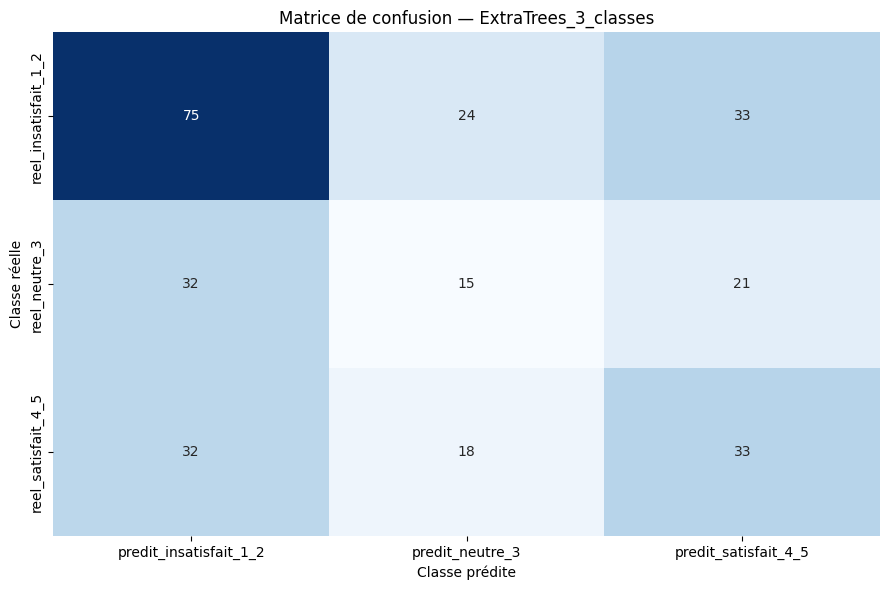

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Matrice de confusion — lignes = réel, colonnes = prédit")
display(confusion_post)

plt.figure(figsize=(9, 6))
sns.heatmap(
    confusion_post,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
)
plt.title(f"Matrice de confusion — {best_model_name}")
plt.xlabel("Classe prédite")
plt.ylabel("Classe réelle")
plt.tight_layout()
plt.show()

### 11.6 Rapport de classification du modèle retenu

In [16]:
display(report_post.round(4))

,precision,recall,f1-score,support
insatisfait_1_2,0.5396,0.5682,0.5535,132.0000
neutre_3,0.2632,0.2206,0.2400,68.0000
satisfait_4_5,0.3793,0.3976,0.3882,83.0000
accuracy,0.4346,0.4346,0.4346,0.4346
macro avg,0.3940,0.3955,0.3939,283.0000
weighted avg,0.4262,0.4346,0.4297,283.0000


### 11.7 Importance des variables du modèle retenu

In [17]:
if hasattr(best_post_pipeline.named_steps["model"], "feature_importances_"):
    feature_names = best_post_pipeline.named_steps["preprocess"].get_feature_names_out()
    importances = best_post_pipeline.named_steps["model"].feature_importances_

    importance_df = (
        pd.DataFrame({
            "feature": feature_names,
            "importance": importances,
        })
        .sort_values("importance", ascending=False)
        .head(20)
    )
    display(importance_df.round(4))
else:
    print("Le modèle retenu ne fournit pas d'importance des variables directement exploitable.")

,feature,importance
13,num__imprevu_present,0.0312
50,cat__imprevus_aucun,0.0306
4,num__respect_budget,0.0281
6,num__part_vol_budget,0.0278
17,num__gravite_imprevu,0.0274
16,num__budget_non_respecte,0.0274
0,num__budget_total,0.0274
5,num__budget_par_jour,0.0265
2,num__prix_vol,0.0264
3,num__reorganisation_necessaire,0.0262


## 12. Model Card — fiche du modèle retenu

Cette fiche documente le modèle post-voyage retenu pour la suite du projet. Elle doit être mise à jour à chaque changement de données, de variables, d'algorithme ou d'hyperparamètres.

### Détails du modèle

| Élément | Description |
| --- | --- |
| Objectif | Prédire / expliquer la satisfaction client après séjour en 3 classes |
| Cible | `satisfaction_client` regroupée en `0 = insatisfait`, `1 = neutre`, `2 = satisfait` |
| Modèle retenu | `ExtraTreesClassifier` dans un pipeline `scikit-learn` |
| Prétraitement | Imputation, encodage OneHot des variables catégorielles et standardisation des variables numériques via `ColumnTransformer` |
| Variables utilisées | Variables pré-voyage + variables post-voyage explicatives (`imprevus`, `reorganisation_necessaire`, `respect_budget`) |
| Variables exclues | `trip_id`, `satisfaction_client`, `retour_client` brut |
| Split d'évaluation | Train/test stratifié, 80 % entraînement et 20 % test |
| Validation complémentaire | Validation croisée à 3 plis |

### Hyperparamètres principaux

| Hyperparamètre | Valeur |
| --- | ---: |
| `n_estimators` | 120 |
| `max_depth` | 8 |
| `class_weight` | `balanced` |
| `random_state` | 42 |
| `n_jobs` | 1 |

### Performances globales

Sur le jeu de test, le modèle retenu obtient environ :

| Métrique | Valeur |
| --- | ---: |
| `accuracy` | 0.4346 |
| `balanced_accuracy` | 0.3955 |
| `macro_f1` | 0.3939 |

La validation croisée confirme un niveau de performance comparable : `macro_f1` moyen autour de 0.3988 avec un écart-type d'environ 0.0261.

### Performances par classe

| Classe | Précision | Rappel | F1-score | Support |
| --- | ---: | ---: | ---: | ---: |
| Insatisfait `1-2` | 0.5396 | 0.5682 | 0.5535 | 132 |
| Neutre `3` | 0.2632 | 0.2206 | 0.2400 | 68 |
| Satisfait `4-5` | 0.3793 | 0.3976 | 0.3882 | 83 |

La classe `neutre` est la moins bien prédite. Cette faiblesse est cohérente avec la difficulté métier : une satisfaction moyenne peut résulter de situations très différentes.

### Performances par sous-groupes

La partie suivante calcule les performances par sous-groupes métier. Les résultats doivent être interprétés avec prudence lorsque le `support` est faible.

### Considérations éthiques et biais identifiés

- Le dataset est synthétique : il ne garantit pas une représentativité réelle des clients, destinations ou profils de voyageurs.
- Les variables comme `budget_total`, `destination`, `client_type` ou `type_hebergement` peuvent introduire des biais socio-économiques dans les recommandations. !!!!!!
- Le modèle post-voyage utilise des événements observés pendant ou après le séjour ; il ne doit pas être présenté comme un outil de prédiction avant départ.
- Les décisions commerciales ne doivent pas être automatisées uniquement à partir du score du modèle. Le résultat doit rester une aide à l'analyse. !!!
- En cas d'utilisation de données réelles, les exigences RGPD, l'anonymisation et le contrôle des accès deviennent obligatoires.

### Cas d'usage recommandés

- Identifier les facteurs associés à une satisfaction faible après séjour.
- Prioriser les dossiers nécessitant une analyse qualité ou une action corrective.
- Comparer l'impact des imprévus, du respect du budget et des réorganisations sur l'expérience client.
- Alimenter une démarche d'amélioration continue des offres de voyages.

### Limitations

- Les performances restent modérées : le modèle est exploitable pour l'analyse, mais insuffisant pour une décision automatique individuelle.
- La prédiction de la classe `neutre` reste fragile.
- Le modèle dépend fortement de variables post-voyage ; il ne répond donc pas au besoin pré-voyage de personnalisation avant départ.
- Les résultats doivent être réévalués après tout enrichissement du dataset, ajout de données réelles ou changement de cible métier.


In [ ]:
def evaluer_performance_sous_groupes(X_test, y_true, y_pred, colonnes_sous_groupes, min_support=20):
    donnees_eval = X_test.reset_index(drop=True).copy()
    y_true_eval = pd.Series(y_true).reset_index(drop=True)
    y_pred_eval = pd.Series(y_pred).reset_index(drop=True)

    lignes = []
    for colonne in colonnes_sous_groupes:
        if colonne not in donnees_eval.columns:
            continue

        for valeur, index_groupe in donnees_eval.groupby(colonne, dropna=False).groups.items():
            index_groupe = list(index_groupe)
            support = len(index_groupe)
            if support < min_support:
                continue

            y_true_groupe = y_true_eval.loc[index_groupe]
            y_pred_groupe = y_pred_eval.loc[index_groupe]

            lignes.append({
                "sous_groupe": colonne,
                "valeur": valeur,
                "support": support,
                "accuracy": accuracy_score(y_true_groupe, y_pred_groupe),
                "balanced_accuracy": balanced_accuracy_score(y_true_groupe, y_pred_groupe),
                "macro_f1": f1_score(
                    y_true_groupe,
                    y_pred_groupe,
                    labels=labels_3_classes,
                    average="macro",
                    zero_division=0,
                ),
            })

    return (
        pd.DataFrame(lignes)
        .sort_values(["sous_groupe", "macro_f1"], ascending=[True, False])
        .reset_index(drop=True)
    )


colonnes_sous_groupes_model_card = [
    "client_type",
    "respect_budget",
    "imprevus",
    "reorganisation_necessaire",
    "meteo_prevue",
]

performances_sous_groupes_post = evaluer_performance_sous_groupes(
    X_test_post,
    y_test_post,
    best_predictions,
    colonnes_sous_groupes_model_card,
    min_support=20,
)

display(performances_sous_groupes_post.round(4))


## 13. Synthèse finale

| Axe | Conclusion |
| --- | --- |
| Pré-voyage | Modèle conforme au besoin de planification, mais performance limitée par le manque de signal disponible avant départ. |
| Post-voyage | Modèle plus pertinent en 3 classes, car les variables opérationnelles expliquent mieux la satisfaction. |
| NLP `retour_client` | Utile pour l'analyse qualitative, mais non retenu dans le modèle principal car trop proche de la satisfaction. |
| SMOTE / XGBoost / RF optimisé | Testés comme améliorations, mais non retenus si le `macro_f1` ne dépasse pas le meilleur modèle simple. |

Le modèle à préparer pour l'étape suivante est donc le meilleur modèle post-voyage 3 classes sans texte libre.

## 14. Références documentaires du projet


In [18]:
documents = pd.DataFrame([
    {
        "document": "docs/etat_projet.md",
        "role": "historique technique du projet, environnement, Docker, Git, Jupyter",
    },
    {
        "document": "docs/objectif_1_dataset.md",
        "role": "identification du dataset, besoins métiers, cas d'usage, datasheet",
    },
    {
        "document": "docs/experiences_modelisation.md",
        "role": "détail des expériences de modélisation et conclusions",
    },
    {
        "document": "notebooks/Exam.ipynb",
        "role": "notebook pré-voyage détaillé et historique",
    },
    {
        "document": "notebooks/objectif_2_post_voyage.ipynb",
        "role": "notebook post-voyage détaillé et historique",
    },
])

display(documents)

,document,role
0,docs/etat_projet.md,"historique technique du projet, environnement,..."
1,docs/objectif_1_dataset.md,"identification du dataset, besoins métiers, ca..."
2,docs/experiences_modelisation.md,détail des expériences de modélisation et conc...
3,notebooks/Exam.ipynb,notebook pré-voyage détaillé et historique
4,notebooks/objectif_2_post_voyage.ipynb,notebook post-voyage détaillé et historique
